# Example Usage: Bias-Corrected Correlation Toolbox

This notebook demonstrates how to use the Bias-Corrected Correlation Toolbox for:

1. **Analyzing existing data** - Compute naive and corrected correlations with confidence intervals
2. **Planning future studies** - Simulate data to determine optimal sample sizes and measurement protocols

This tutorial is associated with the following paper:

*Bruns, A., *Hu, F., Kim, M., Winawer, J., & Pelli, D. G. When to correct correlations for attenuation: A toolbox and tutorial.

*Shared first authorship

## Background

When measuring the correlation between two tasks or variables, measurement noise causes the observed correlation to underestimate the true correlation. This is called **attenuation**.

The classical correction formula (Spearman, 1904) is:

$$r_{corrected} = \frac{r_{observed}}{\sqrt{\text{reliability}_X \times \text{reliability}_Y}}$$

This toolbox helps you:
- Estimate the reliability of variables
- Apply the correction
- Quantify uncertainty via bootstrap confidence intervals
- Determine when correction is beneficial via simulation

## Dataset

We will implement the tutorial with a dataset containing visual crowding thresholds and RSVP reading speeds.

In [9]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys

# Add toolbox to path (fill in the path to where you saved the toolbox)
sys.path.insert(0, '/Users/annabruns/Documents/~NYU/Research/Crowding/correlation/github/crowding-individual-difference/toolbox-and-tutorial')

# Import toolbox modules
from correlationToolbox import (
    # Core analysis
    TaskParameters,
    analyze_correlation,
    analyze_all_pairs,
    summarize_task_statistics,
    compute_reliability,
    
    # Simulation
    simulate_data,
    run_simulation,
    run_simulation_grid,
    get_simulation_distributions,
    
    # Visualization
    set_publication_style,
    plot_correlation_heatmaps,
    plot_correlation_histograms,
    plot_rmse_comparison,
    plot_simulation_summary,
    plot_scatter_with_reliability,
)

# Load data
df_trials = pd.read_csv('rsvp_crowding_trials.csv')

# Set nice plot defaults
set_publication_style()
#np.random.seed(42)

In [10]:
df_trials.head()

,prolificID,taskName,trial_index,repeat1,repeat2
0,559ad287fdf99b219a612d22,crowding,1,0.301030,0.301030
1,559ad287fdf99b219a612d22,crowding,2,0.301030,0.902646
2,559ad287fdf99b219a612d22,crowding,3,0.517937,0.902646
3,559ad287fdf99b219a612d22,crowding,4,0.740871,0.454913
4,559ad287fdf99b219a612d22,crowding,5,0.913474,0.822467


In [11]:
# Build desired datasets
# FINAL THRESHOLDS: Keep only the final thresholds for both tasks (trial_index 25 for rsvp and 36 for crowding)

df_full = df_trials[
    ((df_trials['taskName'] == 'rsvp') & (df_trials['trial_index'] == 25)) |
    ((df_trials['taskName'] == 'crowding') & (df_trials['trial_index'] == 36))
]

df_full = df_full.drop(columns=['trial_index'], errors='ignore')

# Pivot to create task-specific repeat columns
df_full = df_full.pivot(
    index=['prolificID'], 
    columns='taskName', 
    values=['repeat1', 'repeat2']
).reset_index()

# Flatten the multi-level column names
df_full.columns = [
    f'{task}_{repeat}' if task else repeat 
    for repeat, task in df_full.columns
]

df_full['crowding_mean'] = df_full[['crowding_repeat1', 'crowding_repeat2']].mean(axis=1)
df_full['rsvp_mean'] = df_full[['rsvp_repeat1', 'rsvp_repeat2']].mean(axis=1)

# Count participants with non-NaN values for both tasks
both_tasks = df_full.dropna(subset=['crowding_mean', 'rsvp_mean'])
print(f"Participants with both tasks: {len(both_tasks)}")

# Display result
print(df_full.shape)
df_full.head()

Participants with both tasks: 93
(159, 7)


,prolificID,crowding_repeat1,rsvp_repeat1,crowding_repeat2,rsvp_repeat2,crowding_mean,rsvp_mean
0,559ad287fdf99b219a612d22,0.840214,2.524268,0.892139,2.743884,0.866177,2.634076
1,55d51a6b8ce09000127d4821,0.085567,NaN,0.047713,NaN,0.066640,NaN
2,5685850c333cbd000d4e042f,NaN,3.243749,NaN,3.274938,NaN,3.259344
3,56b78f11e77ebe000cbefe79,NaN,3.038987,NaN,3.252026,NaN,3.145507
4,57334d427d01ed00098e8e69,0.362388,3.190956,0.148318,3.088284,0.255353,3.139620


In [12]:
# INTERMEDIATE THRESHOLDS: Keep thresholds earlier in the staircase 

df_noisy = df_trials[
    ((df_trials['taskName'] == 'rsvp') & (df_trials['trial_index'] == 4)) |
    ((df_trials['taskName'] == 'crowding') & (df_trials['trial_index'] == 8))
]

df_noisy = df_noisy.drop(columns=['trial_index'], errors='ignore')

# Pivot to create task-specific repeat columns
df_noisy = df_noisy.pivot(
    index=['prolificID'], 
    columns='taskName', 
    values=['repeat1', 'repeat2']
).reset_index()

# Flatten the multi-level column names
df_noisy.columns = [
    f'{task}_{repeat}' if task else repeat 
    for repeat, task in df_noisy.columns
]

df_noisy['crowding_mean'] = df_noisy[['crowding_repeat1', 'crowding_repeat2']].mean(axis=1)
df_noisy['rsvp_mean'] = df_noisy[['rsvp_repeat1', 'rsvp_repeat2']].mean(axis=1)

# Count participants with non-NaN values for both tasks
both_tasks = df_noisy.dropna(subset=['crowding_mean', 'rsvp_mean'])
print(f"Participants with both tasks: {len(both_tasks)}")

# Display result
print(df_noisy.shape)
df_noisy.head()

Participants with both tasks: 93
(159, 7)


,prolificID,crowding_repeat1,rsvp_repeat1,crowding_repeat2,rsvp_repeat2,crowding_mean,rsvp_mean
0,559ad287fdf99b219a612d22,0.663053,2.496419,0.898119,2.496419,0.780586,2.496419
1,55d51a6b8ce09000127d4821,0.081052,NaN,0.257192,NaN,0.169122,NaN
2,5685850c333cbd000d4e042f,NaN,3.161463,NaN,3.161463,NaN,3.161463
3,56b78f11e77ebe000cbefe79,NaN,3.161463,NaN,3.161463,NaN,3.161463
4,57334d427d01ed00098e8e69,0.217168,3.161463,0.185082,3.161463,0.201125,3.161463


---

# Part 1: Analyze data

Use this workflow when you have collected data with 2+ measurements/repeats for 2+ variables/tasks.

In [13]:
# Grab final thresholds for both tasks (trial_index 25 for rsvp and 36 for crowding)
crowding_measurements = df_full[['crowding_repeat1', 'crowding_repeat2']].reset_index(drop=True)
rsvp_measurements = df_full[['rsvp_repeat1', 'rsvp_repeat2']].reset_index(drop=True)

# Analyze correlation with bootstrap CIs
result = analyze_correlation(
    crowding_measurements,
    rsvp_measurements,
    n_bootstrap=2000,
    confidence_level=0.95,
    random_state=42
)

print(result)

Correlation Analysis Results (N = 93)
r:               -0.393  [-0.574, -0.178]
r_unbiased:      -0.427  [-0.622, -0.199]
Reliability X:   0.912
Reliability Y:   0.925
r_ceiling:       0.919



In [14]:
# Grab intermediate thresholds for both tasks (trial_index 4 for rsvp and 8 for crowding)
crowding_measurements = df_noisy[['crowding_repeat1', 'crowding_repeat2']].reset_index(drop=True)
rsvp_measurements = df_noisy[['rsvp_repeat1', 'rsvp_repeat2']].reset_index(drop=True)

# Analyze correlation with bootstrap CIs
result = analyze_correlation(
    crowding_measurements,
    rsvp_measurements,
    n_bootstrap=2000,
    confidence_level=0.95,
    random_state=42
)

print(result)

Correlation Analysis Results (N = 93)
r:               -0.246  [-0.418, -0.013]
r_unbiased:      -0.363  [-0.594, -0.020]
Reliability X:   0.632
Reliability Y:   0.726
r_ceiling:       0.677



---

# Part 2: Planning Future Studies

Use this workflow to determine optimal sample sizes and measurement protocols. In this demonstration, we use the same task 1 and 2 parameters from Part 1 above.

In [15]:
# Run simulation for a specific design and estimate of true correlation
# Note that task parameters are the same as above

true_correlation = 0.4
n_subjects = 60
n_repeats = 2

sim_result = run_simulation(
    task1_params, task2_params,
    n_subjects=n_subjects,
    n_repeats=n_repeats,
    true_correlation=true_correlation,
    n_iterations=1000,
    random_state=None
)

print(sim_result)

NameError: name 'task1_params' is not defined

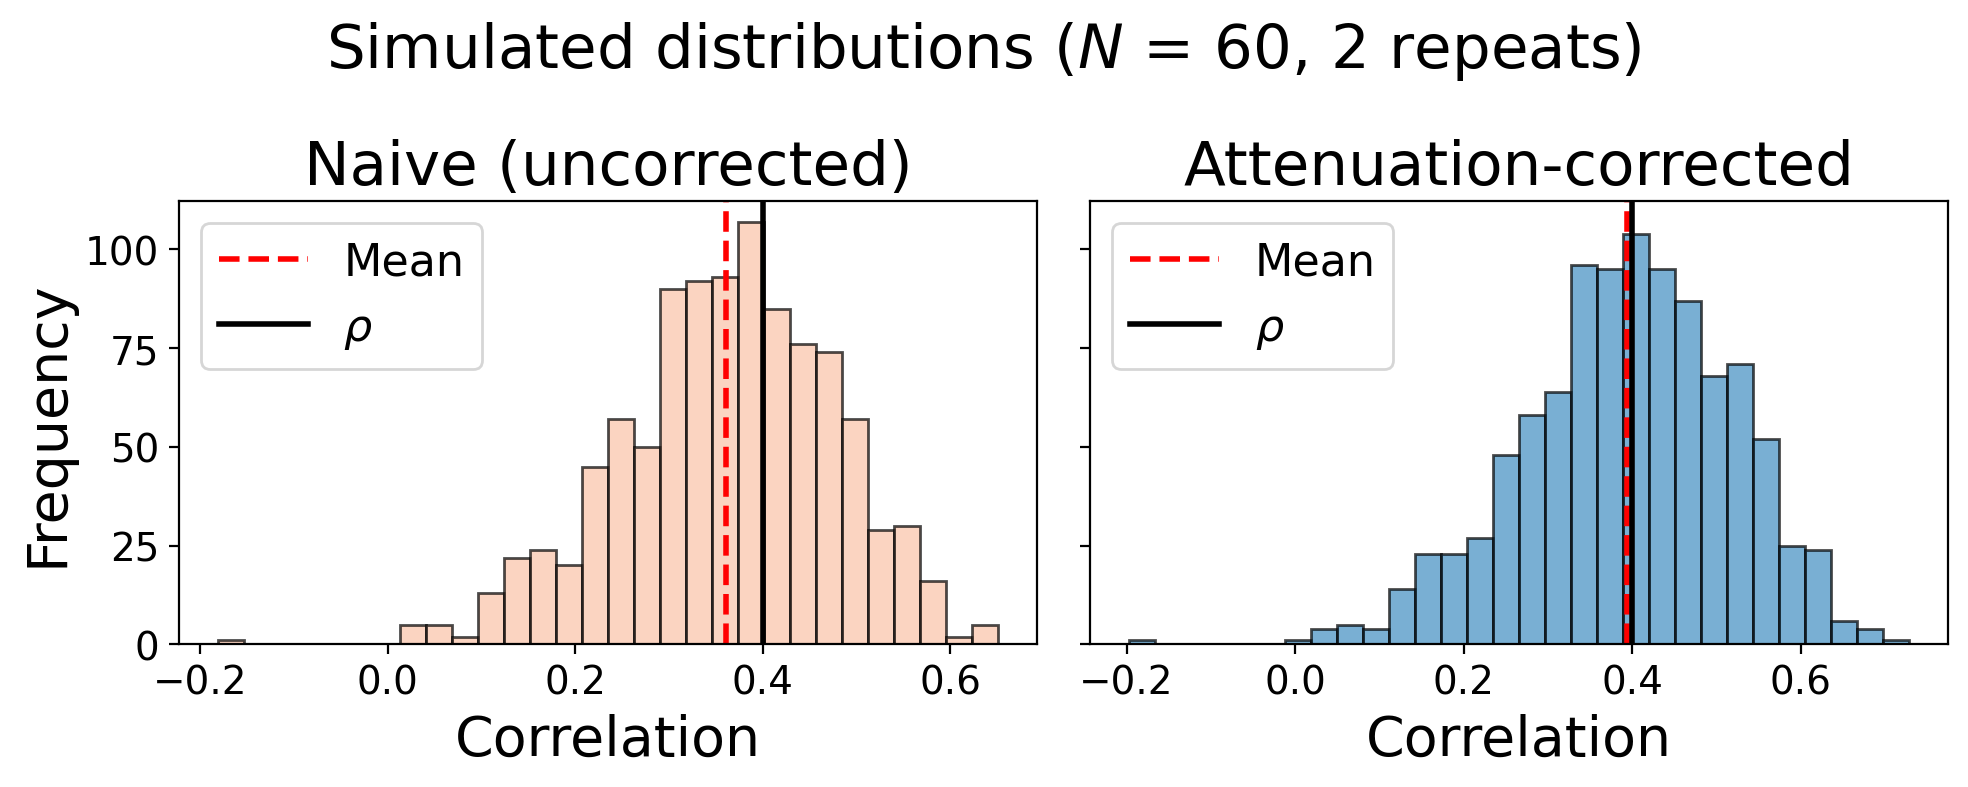

In [ ]:
# Get distributions for visualization
distributions = get_simulation_distributions(
    task1_params, task2_params,
    n_subjects=n_subjects,
    n_repeats=n_repeats,
    true_correlation=true_correlation,
    n_iterations=1000,
    random_state=None
)

fig = plot_correlation_histograms(
    distributions['naive'],
    distributions['corrected'],
    true_correlation=true_correlation,
    title=f'Simulated distributions ($N$ = {n_subjects}, {n_repeats} repeats)'
)
plt.show()

In [159]:
# Run grid search over design parameters
grid_results = run_simulation_grid(
    task1_params, task2_params,
    sample_sizes=[15, 30, 60, 120, 240],
    n_repeats_list=[2, 4, 6],
    true_correlation=true_correlation,
    n_iterations=500,
    random_state=None
)

print("\nSimulation Grid Results:")
grid_results.round(3)

Running condition 1/15: N=15, repeats=2
Running condition 2/15: N=15, repeats=4
Running condition 3/15: N=15, repeats=6
Running condition 4/15: N=30, repeats=2
Running condition 5/15: N=30, repeats=4
Running condition 6/15: N=30, repeats=6
Running condition 7/15: N=60, repeats=2
Running condition 8/15: N=60, repeats=4
Running condition 9/15: N=60, repeats=6
Running condition 10/15: N=120, repeats=2
Running condition 11/15: N=120, repeats=4
Running condition 12/15: N=120, repeats=6
Running condition 13/15: N=240, repeats=2
Running condition 14/15: N=240, repeats=4
Running condition 15/15: N=240, repeats=6

Simulation Grid Results:


,n_subjects,n_repeats,true_correlation,naive_mean,naive_sd,naive_rmse,naive_ci_lower,naive_ci_upper,corrected_mean,corrected_sd,corrected_rmse,corrected_ci_lower,corrected_ci_upper,recommended
0,15,2,0.4,0.359,0.242,0.246,-0.181,0.776,0.394,0.266,0.266,-0.195,0.841,Naive (uncorrected)
1,15,4,0.4,0.374,0.225,0.227,-0.121,0.745,0.394,0.237,0.237,-0.127,0.787,Naive (uncorrected)
2,15,6,0.4,0.391,0.225,0.225,-0.129,0.765,0.405,0.232,0.232,-0.134,0.790,Naive (uncorrected)
3,30,2,0.4,0.353,0.165,0.171,0.007,0.633,0.387,0.179,0.180,0.008,0.688,Naive (uncorrected)
4,30,4,0.4,0.370,0.154,0.157,0.047,0.655,0.389,0.161,0.161,0.049,0.686,Naive (uncorrected)
5,30,6,0.4,0.381,0.153,0.155,0.073,0.650,0.394,0.158,0.158,0.075,0.675,Naive (uncorrected)
6,60,2,0.4,0.363,0.116,0.122,0.128,0.592,0.396,0.125,0.125,0.140,0.645,Naive (uncorrected)
7,60,4,0.4,0.378,0.115,0.117,0.151,0.586,0.396,0.120,0.120,0.160,0.613,Naive (uncorrected)
8,60,6,0.4,0.392,0.115,0.115,0.155,0.606,0.404,0.118,0.118,0.160,0.624,Naive (uncorrected)
9,120,2,0.4,0.361,0.081,0.090,0.191,0.509,0.394,0.088,0.088,0.210,0.558,Corrected


<string>:59: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.


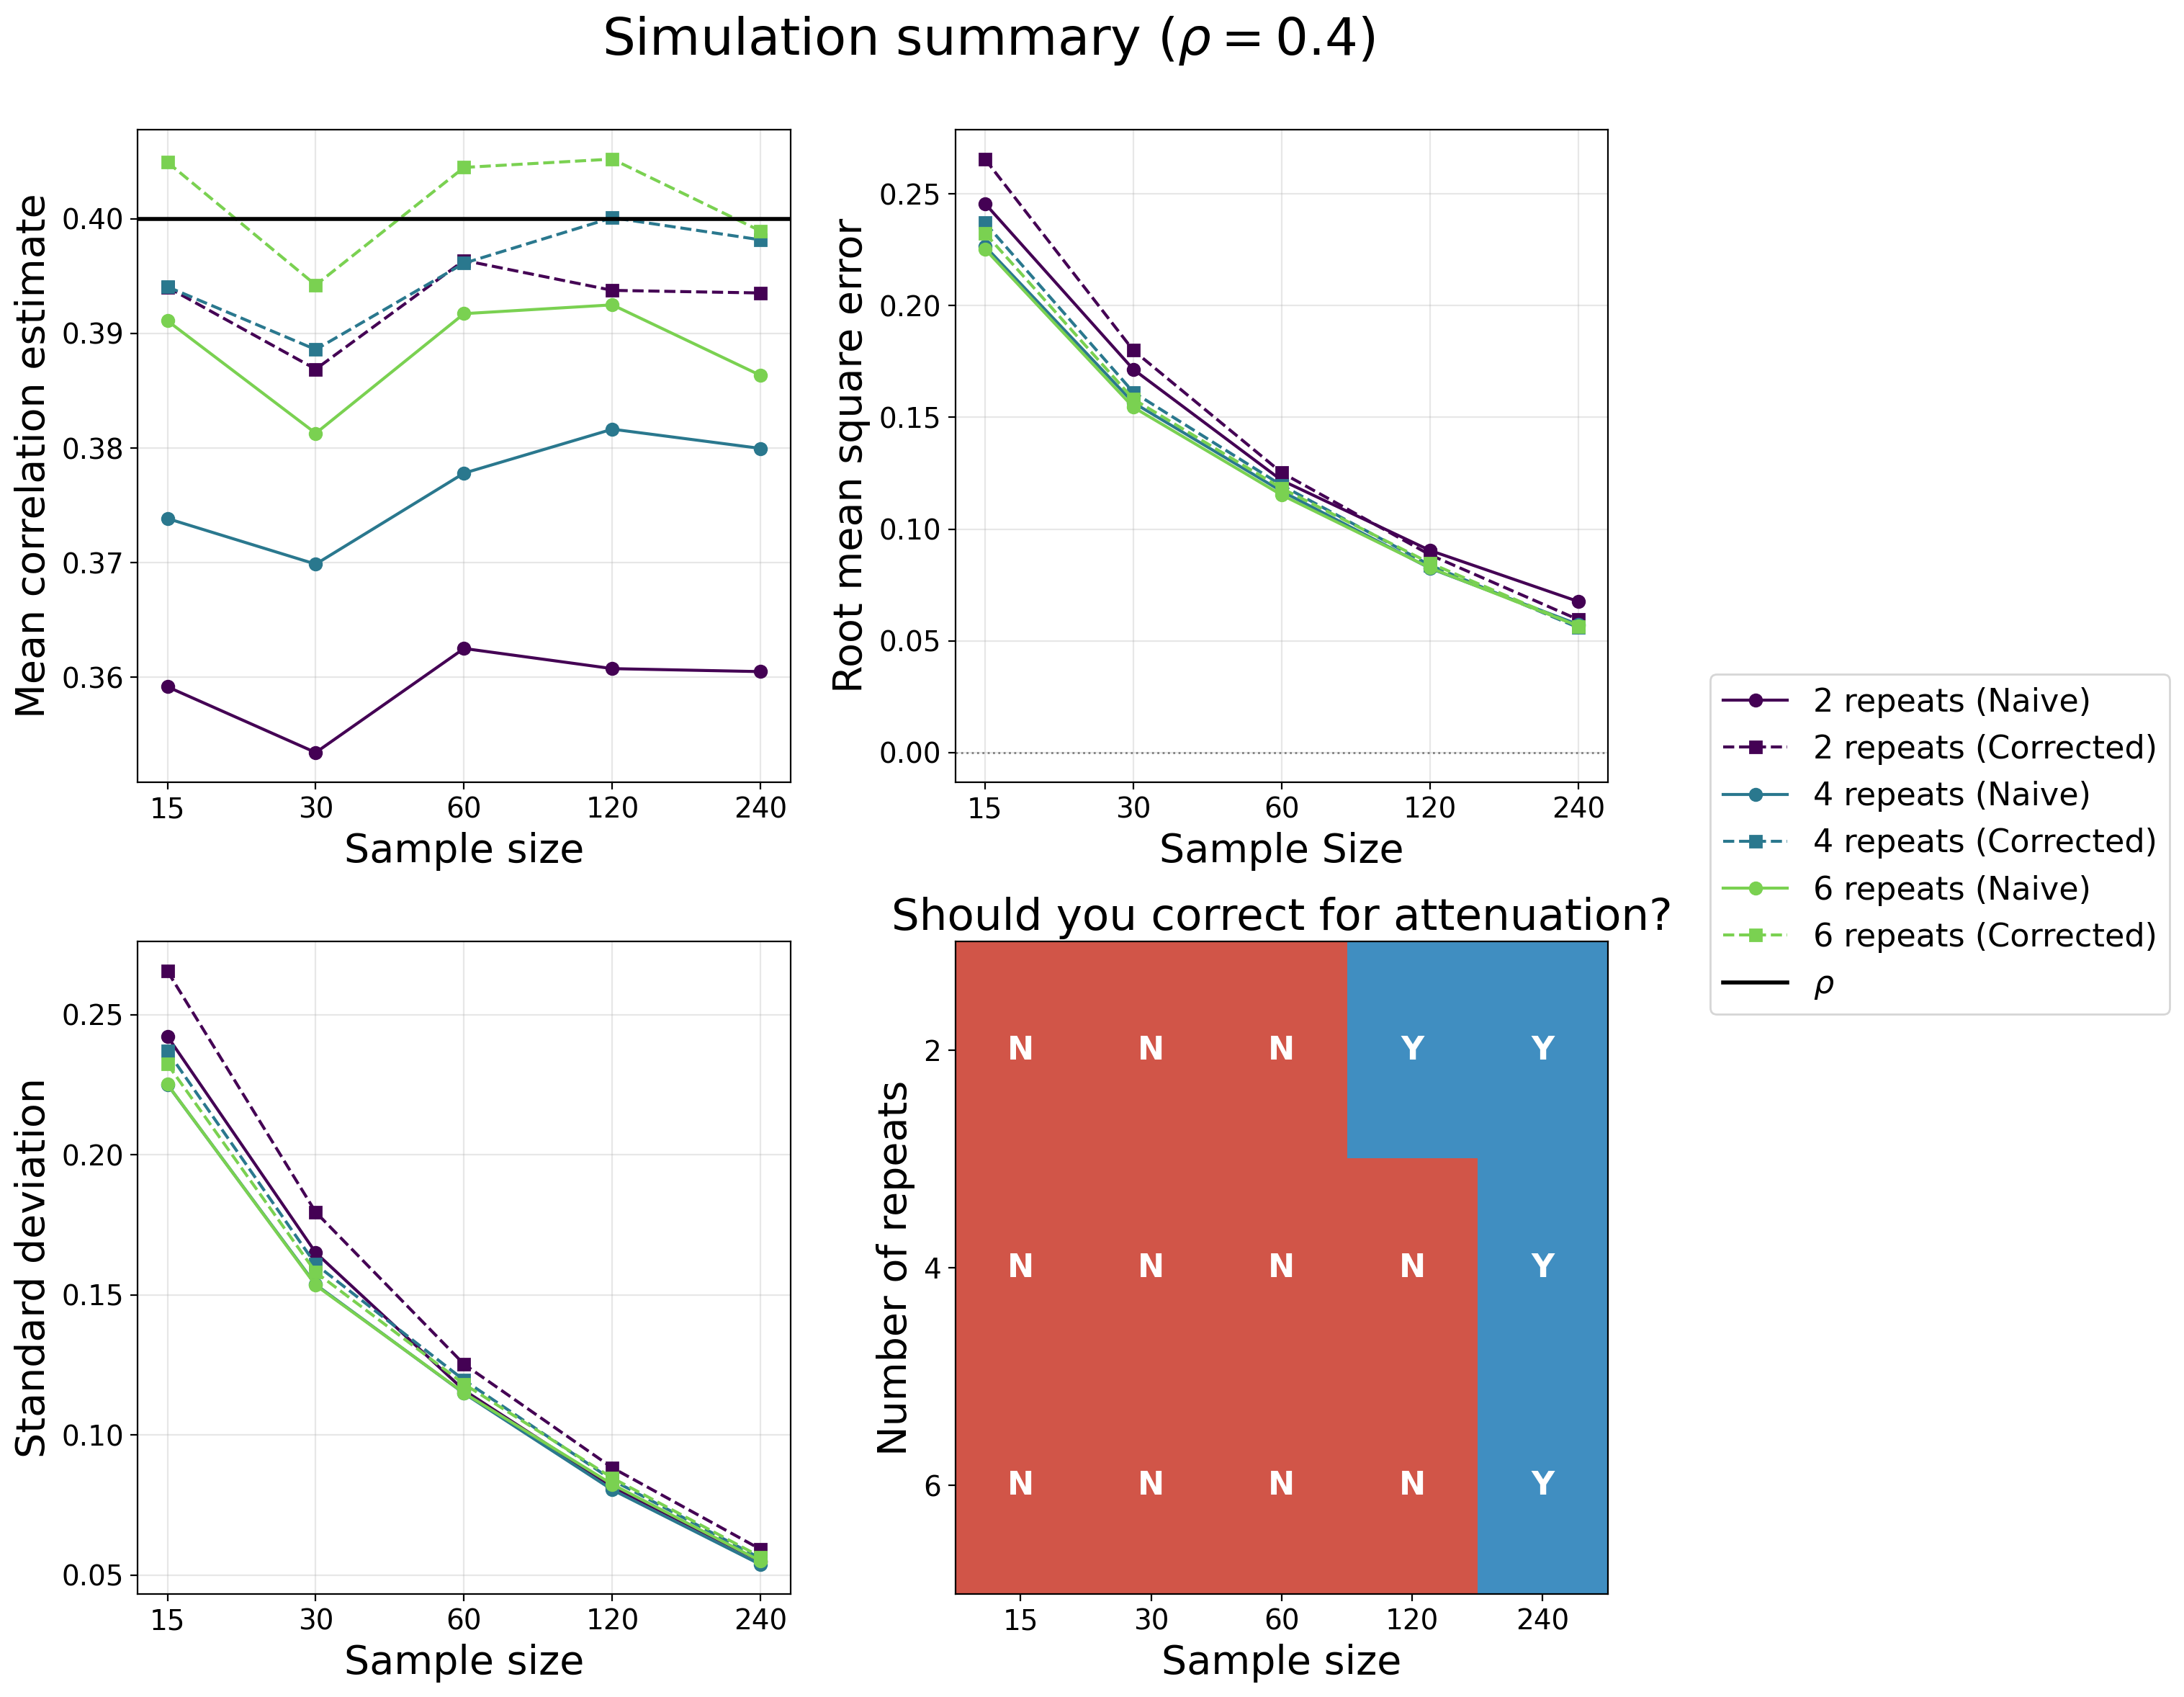

In [160]:
# Comprehensive summary plot
fig = plot_simulation_summary(grid_results, true_correlation=true_correlation)
plt.show()

---

# Summary

## Key Functions

| Function | Use Case |
|----------|----------|
| `analyze_correlation()` | Analyze single pair of tasks |
| `analyze_all_pairs()` | Analyze all pairwise correlations |
| `run_simulation()` | Evaluate estimators for specific design |
| `run_simulation_grid()` | Compare across multiple designs |
| `plot_correlation_heatmaps()` | Visualize naive vs. corrected |
| `plot_simulation_summary()` | Comprehensive simulation results |